# Blok A — Profil stasiun & pemahaman preferensi

Pelengkap `analisis_blok_A_klaim_utama.ipynb`. Dua hal yang tak terlihat dari metrik
agregat:

1. **Utilisasi per stasiun** — Gini hanya satu angka ringkas; sebaran per stasiun
   menunjukkan stasiun mana yang menganggur dan mana yang jenuh.
2. **Pemahaman preferensi** — `acc` mengukur apakah saran diikuti, bukan apakah agen
   benar-benar menebak stasiun yang disukai pengguna. Diuji lewat kontrafaktual
   `sid_pref`.

Seluruh lengan memakai **k=3** dan estimator serta kanal janji yang disetarakan.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.')); sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A, common

pd.set_option('display.width', 240); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .3})

HORIZON = '90d'
B = 'master_hybrid_ppo_dgr_90d_cwtfail120pen-2_preffeat_pairout'
LENGAN = [('sel1 mati',    f'{B}_noattn_pure3',       None),
          ('sel2 attn',    f'{B}_pure3',              None),
          ('sel3 P',       f'{B}_pg0.1_noattn_pure3', None),
          ('sel4 attn+P',  f'{B}_pg0.1_pure3',        None),
          ('greedy_queue', 'greedy_setara_k3', 'greedy_queue|signed|dinamis')]

## 1. Profil klaster

Ketimpangan bawaan lingkungan — inilah yang harus diatasi sistem.

In [2]:
sim = common.fresh_sim(os.path.join(common.ROOT, 'scenario_dataset_klaster12_4x_90d.json'))
baris = []
for sid, s in sim.spklus.items():
    kap = dict(s.capacities)
    baris.append({'stasiun': sid, 'AC': kap.get('AC', 0), 'DC': kap.get('DC', 0),
                  'total_konektor': sum(kap.values()),
                  'popularitas': sim.spklu_features[sid].get('pop')})
prof = pd.DataFrame(baris).set_index('stasiun')
prof['pop_per_konektor'] = prof['popularitas'] / prof['total_konektor']
display(prof.round(2))
print('SPKLU_00: popularitas TERTINGGI dgn kapasitas TERKECIL (1 konektor) ->')
print('  beban per konektor 21,9 vs SPKLU_03 hanya 0,58. Rasio 38x.')
print('DC melayani ~49 mnt, AC ~136 mnt -> stasiun ber-DC melayani lebih banyak EV')
print('  pada okupansi yang sama. Inilah sebab gini(transaksi) != gini(utilisasi).')

,AC,DC,total_konektor,popularitas,pop_per_konektor
stasiun,,,,,
SPKLU_00,0,1,1,21.94,21.94
SPKLU_01,1,1,2,4.41,2.20
SPKLU_02,4,0,4,3.64,0.91
SPKLU_03,4,0,4,2.32,0.58
SPKLU_04,3,1,4,8.16,2.04
SPKLU_05,1,1,2,3.87,1.94


SPKLU_00: popularitas TERTINGGI dgn kapasitas TERKECIL (1 konektor) ->
  beban per konektor 21,9 vs SPKLU_03 hanya 0,58. Rasio 38x.
DC melayani ~49 mnt, AC ~136 mnt -> stasiun ber-DC melayani lebih banyak EV
  pada okupansi yang sama. Inilah sebab gini(transaksi) != gini(utilisasi).


## 2. Utilisasi per stasiun

In [3]:
def per_stasiun(tag, lengan, field):
    d = A.muat(tag, HORIZON)
    k = lengan or list(d['agregat'])[0]
    runs = [r['_stasiun'] for r in d['per_seed'][k]]
    return {s: float(np.mean([r[s][field] for r in runs])) for s in runs[0]}

def tabel_stasiun(field, judul, r=4):
    baris = []
    for n, t, l in LENGAN:
        v = per_stasiun(t, l, field)
        row = {'lengan': n}; row.update(v)
        row['SD antar-stasiun'] = float(np.std(list(v.values())))
        baris.append(row)
    df = pd.DataFrame(baris).set_index('lengan')
    print(f'\n=== {judul} ===')
    display(df.round(r))
    return df

util  = tabel_stasiun('util_mean', 'UTILISASI RERATA per stasiun')
queue = tabel_stasiun('queue_mean', 'PANJANG ANTREAN RERATA per stasiun', 3)
kosong = tabel_stasiun('frac_jam_kosong', 'FRAKSI JAM MENGANGGUR per stasiun')
antre = tabel_stasiun('frac_jam_antre', 'FRAKSI JAM ADA ANTREAN per stasiun')


=== UTILISASI RERATA per stasiun ===


,SPKLU_00,SPKLU_01,SPKLU_02,SPKLU_03,SPKLU_04,SPKLU_05,SD antar-stasiun
lengan,,,,,,,
sel1 mati,0.7232,0.7245,0.7278,0.7022,0.6943,0.6785,0.0182
sel2 attn,0.7207,0.7016,0.7049,0.6662,0.7242,0.7112,0.0190
sel3 P,0.6836,0.7079,0.7367,0.6798,0.7278,0.6896,0.0218
sel4 attn+P,0.7000,0.6781,0.7362,0.7378,0.6950,0.6927,0.0225
greedy_queue,0.6250,0.7111,0.7663,0.6668,0.4860,0.3995,0.1277



=== PANJANG ANTREAN RERATA per stasiun ===


,SPKLU_00,SPKLU_01,SPKLU_02,SPKLU_03,SPKLU_04,SPKLU_05,SD antar-stasiun
lengan,,,,,,,
sel1 mati,1.972,2.105,1.835,1.703,2.433,1.878,0.234
sel2 attn,2.000,2.016,1.706,1.382,2.711,1.962,0.402
sel3 P,1.501,1.752,1.606,1.427,2.465,1.704,0.341
sel4 attn+P,1.300,1.226,1.356,1.340,1.697,1.255,0.156
greedy_queue,0.764,1.125,1.192,0.885,0.497,0.316,0.314



=== FRAKSI JAM MENGANGGUR per stasiun ===


,SPKLU_00,SPKLU_01,SPKLU_02,SPKLU_03,SPKLU_04,SPKLU_05,SD antar-stasiun
lengan,,,,,,,
sel1 mati,0.2768,0.1806,0.0964,0.1104,0.1283,0.2211,0.0643
sel2 attn,0.2793,0.2007,0.1049,0.1300,0.1005,0.1846,0.0629
sel3 P,0.3164,0.1909,0.0910,0.1305,0.1095,0.2085,0.0760
sel4 attn+P,0.3000,0.2206,0.1016,0.0958,0.1301,0.2052,0.0734
greedy_queue,0.3750,0.1619,0.0620,0.1424,0.2950,0.4778,0.1439



=== FRAKSI JAM ADA ANTREAN per stasiun ===


,SPKLU_00,SPKLU_01,SPKLU_02,SPKLU_03,SPKLU_04,SPKLU_05,SD antar-stasiun
lengan,,,,,,,
sel1 mati,0.5525,0.5563,0.4720,0.4375,0.4931,0.4961,0.0422
sel2 attn,0.5233,0.5072,0.4311,0.3818,0.5071,0.5087,0.0518
sel3 P,0.4864,0.5119,0.4580,0.3936,0.5222,0.4928,0.0427
sel4 attn+P,0.4823,0.4621,0.4547,0.4549,0.4651,0.4670,0.0093
greedy_queue,0.3614,0.4702,0.4372,0.3614,0.2350,0.1769,0.1040


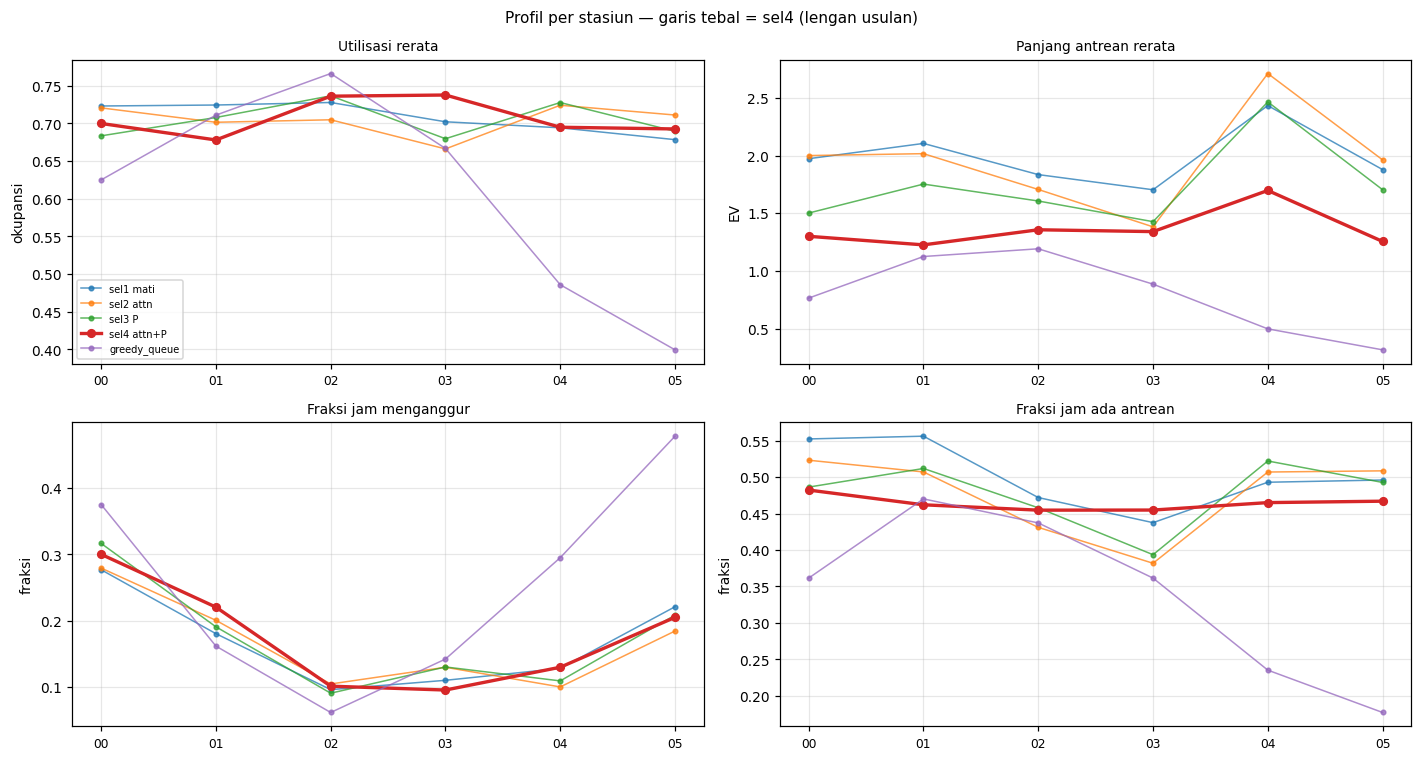

sel4 menahan keenam stasiun di pita sempit pada SEMUA panel.
greedy_queue membiarkan SPKLU_04/05 menganggur (utilisasi 0,49/0,40) sementara
SPKLU_02 mencapai 0,77 -> itulah wujud gini_UTIL 0,1163.


In [4]:
sids = [c for c in util.columns if c.startswith('SPKLU')]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (df, judul, yl) in zip(axes.ravel(), [
        (util, 'Utilisasi rerata', 'okupansi'),
        (queue, 'Panjang antrean rerata', 'EV'),
        (kosong, 'Fraksi jam menganggur', 'fraksi'),
        (antre, 'Fraksi jam ada antrean', 'fraksi')]):
    for n in df.index:
        gaya = dict(lw=2.2, marker='o', ms=5) if n == 'sel4 attn+P' else dict(lw=1, marker='.', alpha=.75)
        ax.plot(sids, df.loc[n, sids].to_numpy(float), label=n, **gaya)
    ax.set_title(judul, fontsize=9); ax.set_ylabel(yl)
    ax.set_xticks(range(len(sids)))
    ax.set_xticklabels([s.replace('SPKLU_', '') for s in sids], fontsize=8)
axes[0][0].legend(fontsize=6.5)
plt.suptitle('Profil per stasiun — garis tebal = sel4 (lengan usulan)', fontsize=10)
plt.tight_layout(); plt.show()

print('sel4 menahan keenam stasiun di pita sempit pada SEMUA panel.')
print('greedy_queue membiarkan SPKLU_04/05 menganggur (utilisasi 0,49/0,40) sementara')
print('SPKLU_02 mencapai 0,77 -> itulah wujud gini_UTIL 0,1163.')

In [5]:
print('KESERAGAMAN antar-stasiun (SD; makin kecil makin merata)\n')
ring = pd.DataFrame({
    'util':   util['SD antar-stasiun'],
    'antrean': queue['SD antar-stasiun'],
    'jam_kosong': kosong['SD antar-stasiun'],
    'jam_antre': antre['SD antar-stasiun']})
display(ring.round(4))
print('sel4 paling seragam pada jam_antre (SD 0,0093) -- keenam stasiun mengantre pada')
print('fraksi waktu yang hampir identik. Itu wujud operasional dari Gini utilisasi 0,0206.')

KESERAGAMAN antar-stasiun (SD; makin kecil makin merata)



,util,antrean,jam_kosong,jam_antre
lengan,,,,
sel1 mati,0.0182,0.2340,0.0643,0.0422
sel2 attn,0.0190,0.4015,0.0629,0.0518
sel3 P,0.0218,0.3415,0.0760,0.0427
sel4 attn+P,0.0225,0.1564,0.0734,0.0093
greedy_queue,0.1277,0.3145,0.1439,0.1040


sel4 paling seragam pada jam_antre (SD 0,0093) -- keenam stasiun mengantre pada
fraksi waktu yang hampir identik. Itu wujud operasional dari Gini utilisasi 0,0206.


## 3. Pemahaman preferensi

`acc` tidak membedakan "agen menebak preferensi dengan tepat" dari "pengguna kebetulan
menurut". Kontrafaktual `sid_pref` (stasiun yang akan dipilih tanpa rekomendasi)
memungkinkan pengujian langsung:

| metrik | arti | tingkat kebetulan |
|---|---|---|
| `pref_primer` | stasiun preferensi ditaruh di slot **pertama** | $1/6 \approx 0{,}167$ |
| `pref_dalam` | stasiun preferensi **ada** di himpunan rekomendasi | $k/6 = 0{,}500$ untuk k=3 |

Agen yang benar-benar memahami preferensi harus **melampaui** ambang tersebut.

> **Belum tersedia untuk lengan RL.** Metrik ini ditambahkan ke `_uji_konsolidasi.py`
> pada 2026-08-31, setelah berkas hasil RL dibuat. Mendapatkannya memerlukan evaluasi
> ulang (bukan latih ulang) dengan checkpoint `.pt` yang ada di server.

In [6]:
M = ['pref_primer', 'pref_dalam', 'patuh_bila_pref_ada', 'patuh_bila_pref_tiada', 'acc']
baris = []
for n, t, l in LENGAN:
    r = {'lengan': n}
    for m in M:
        try:
            r[m] = A.unit_stat(t, m, HORIZON, l)[0]
        except KeyError:
            r[m] = np.nan
    baris.append(r)
pref = pd.DataFrame(baris).set_index('lengan')
pref['acc_rekonstruksi'] = (pref['pref_dalam'] * pref['patuh_bila_pref_ada']
                            + (1 - pref['pref_dalam']) * pref['patuh_bila_pref_tiada'])
display(pref.round(4))
print('NaN = berkas hasil dibuat sebelum metrik ini ada (perlu evaluasi ulang).')

,pref_primer,pref_dalam,patuh_bila_pref_ada,patuh_bila_pref_tiada,acc,acc_rekonstruksi
lengan,,,,,,
sel1 mati,0.1618,0.4903,0.9703,0.3820,0.6700,0.6705
sel2 attn,0.1798,0.5163,0.9686,0.4196,0.7021,0.7031
sel3 P,0.1774,0.5182,0.9692,0.4179,0.7034,0.7036
sel4 attn+P,0.1697,0.5125,0.9675,0.4580,0.7194,0.7192
greedy_queue,0.1607,0.4954,0.9694,0.4678,0.7165,0.7163


NaN = berkas hasil dibuat sebelum metrik ini ada (perlu evaluasi ulang).


### 3.1 Dekomposisi `acc` — dan mengapa ia bukan ukuran kualitas

$$\texttt{acc} = P(\text{pref ada}) \cdot p_{\text{ada}} + P(\text{pref tiada}) \cdot p_{\text{tiada}}$$

Rekonstruksi cocok sampai <0,0005, jadi `acc` **sepenuhnya** terjelaskan oleh dua hal:
seberapa sering preferensi ikut ditawarkan, dan kepatuhan bersyarat pada dua kondisi itu.

In [7]:
g = pref.dropna(subset=['pref_dalam'])
for n in g.index:
    a, b = g.loc[n, 'patuh_bila_pref_ada'], g.loc[n, 'patuh_bila_pref_tiada']
    print(f'{n:14s} kepatuhan {a:.3f} bila preferensi DITAWARKAN vs {b:.3f} bila TIDAK'
          f'   (rasio {a/b:.2f}x)')
print()
print('Kepatuhan melonjak ~2x ketika stasiun favorit pengguna ada di daftar.')
print('-> `acc` terutama mengukur SEBERAPA SERING preferensi tertangkap, bukan')
print('   seberapa persuasif rekomendasinya.')

sel1 mati      kepatuhan 0.970 bila preferensi DITAWARKAN vs 0.382 bila TIDAK   (rasio 2.54x)
sel2 attn      kepatuhan 0.969 bila preferensi DITAWARKAN vs 0.420 bila TIDAK   (rasio 2.31x)
sel3 P         kepatuhan 0.969 bila preferensi DITAWARKAN vs 0.418 bila TIDAK   (rasio 2.32x)
sel4 attn+P    kepatuhan 0.967 bila preferensi DITAWARKAN vs 0.458 bila TIDAK   (rasio 2.11x)
greedy_queue   kepatuhan 0.969 bila preferensi DITAWARKAN vs 0.468 bila TIDAK   (rasio 2.07x)

Kepatuhan melonjak ~2x ketika stasiun favorit pengguna ada di daftar.
-> `acc` terutama mengukur SEBERAPA SERING preferensi tertangkap, bukan
   seberapa persuasif rekomendasinya.


### 3.2 Uji mekanisme: k=2 vs k=3

Bila `pref_dalam` benar-benar hanya peluang acak untuk agen buta-pengguna, maka
mengubah k harus menggesernya persis ke $k/6$ — dan `pref_primer` harus **tidak**
bergerak (memperbesar jala tak membuat slot pertama lebih tepat).

In [8]:
UJI = [('g_queue k=2', 'greedy_setara_k2', 'greedy_queue|signed|dinamis'),
       ('g_queue k=3', 'greedy_setara_k3', 'greedy_queue|signed|dinamis'),
       ('g_util k=2',  'greedy_setara_k2', 'greedy_util|signed|dinamis'),
       ('g_util k=3',  'greedy_setara_k3', 'greedy_util|signed|dinamis')]
baris = []
for n, t, l in UJI:
    r = {'lengan': n, 'k': int(n[-1])}
    for m in ['pref_primer', 'pref_dalam', 'acc']:
        r[m] = A.unit_stat(t, m, HORIZON, l)[0]
    r['harapan k/6'] = r['k'] / 6
    r['harapan 1/6'] = 1 / 6
    baris.append(r)
uji = pd.DataFrame(baris).set_index('lengan')
display(uji[['k', 'pref_dalam', 'harapan k/6', 'pref_primer', 'harapan 1/6', 'acc']].round(4))
print('pref_dalam meleset <1,5 poin persen dari k/6; pref_primer tak bergerak (0,16-0,17).')
print('-> greedy SEPENUHNYA buta terhadap preferensi, persis seperti seharusnya.')
print()
print('KONSEKUENSI: menaikkan k menaikkan acc ~0,10 TANPA mengubah kebijakan sama sekali.')
print('Perbandingan lintas-lengan dgn k berbeda TIDAK SAH -- pada acc maupun metrik lain.')

,k,pref_dalam,harapan k/6,pref_primer,harapan 1/6,acc
lengan,,,,,,
g_queue k=2,2,0.3363,0.3333,0.1710,0.1667,0.6124
g_queue k=3,3,0.4954,0.5000,0.1607,0.1667,0.7165
g_util k=2,2,0.3442,0.3333,0.1722,0.1667,0.6405
g_util k=3,3,0.5112,0.5000,0.1637,0.1667,0.7363


pref_dalam meleset <1,5 poin persen dari k/6; pref_primer tak bergerak (0,16-0,17).
-> greedy SEPENUHNYA buta terhadap preferensi, persis seperti seharusnya.

KONSEKUENSI: menaikkan k menaikkan acc ~0,10 TANPA mengubah kebijakan sama sekali.
Perbandingan lintas-lengan dgn k berbeda TIDAK SAH -- pada acc maupun metrik lain.


### 3.3 Ambang uji untuk Modul P

Ketika evaluasi RL dijalankan ulang, klaim "Modul P memahami preferensi" (IV.1.8,
Tujuan Teknis 1) diuji dengan ambang berikut:

| hasil | tafsir |
|---|---|
| `pref_dalam` ≈ 0,50 **dan** `pref_primer` ≈ 0,167 | Modul P **tidak** memahami preferensi; keunggulan sel4 berasal dari dimensi lain |
| `pref_dalam` > 0,50 | Modul P benar-benar menangkap preferensi laten |
| `pref_primer` > 0,167 | lebih kuat lagi: agen menaruh stasiun yang tepat di slot utama |
| `patuh_bila_pref_tiada` > 0,47 | agen lebih **persuasif** — mampu menggeser pengguna meski preferensinya tak ditawarkan |

Kemungkinan terakhir menarik tersendiri: menggeser pengguna dari preferensinya justru
yang dibutuhkan pemerataan, jadi unggul di situ akan lebih bermakna daripada sekadar
menebak preferensi dengan tepat.

In [9]:
# Perkiraan berdasarkan acc yang sudah diketahui, MENGANDAIKAN kepatuhan bersyarat
# sama dengan greedy. Ini INFERENSI, bukan pengukuran -- untuk menetapkan ekspektasi.
p_ada = pref.loc['greedy_queue', 'patuh_bila_pref_ada']
p_tia = pref.loc['greedy_queue', 'patuh_bila_pref_tiada']
print('Perkiraan pref_dalam lengan RL (andai kepatuhan bersyarat = greedy):\n')
for n, t, l in LENGAN[:4]:
    acc = A.unit_stat(t, 'acc', HORIZON, l)[0]
    est = (acc - p_tia) / (p_ada - p_tia)
    print(f'  {n:14s} acc={acc:.4f} -> pref_dalam ~ {est:.4f}'
          f'   ({"di atas" if est > 0.5 else "SEKITAR/di bawah"} kebetulan 0,500)')
print()
print('PERINGATAN: ini inferensi dari satu persamaan dgn dua bilangan tak diketahui.')
print('Bila lengan RL lebih persuasif (patuh_bila_pref_tiada lebih tinggi), pref_dalam')
print('sesungguhnya akan LEBIH RENDAH dari perkiraan ini. Hanya evaluasi ulang yang')
print('dapat memisahkan kedua kemungkinan itu.')

Perkiraan pref_dalam lengan RL (andai kepatuhan bersyarat = greedy):

  sel1 mati      acc=0.6700 -> pref_dalam ~ 0.4032   (SEKITAR/di bawah kebetulan 0,500)
  sel2 attn      acc=0.7021 -> pref_dalam ~ 0.4670   (SEKITAR/di bawah kebetulan 0,500)
  sel3 P         acc=0.7034 -> pref_dalam ~ 0.4696   (SEKITAR/di bawah kebetulan 0,500)
  sel4 attn+P    acc=0.7194 -> pref_dalam ~ 0.5016   (di atas kebetulan 0,500)

PERINGATAN: ini inferensi dari satu persamaan dgn dua bilangan tak diketahui.
Bila lengan RL lebih persuasif (patuh_bila_pref_tiada lebih tinggi), pref_dalam
sesungguhnya akan LEBIH RENDAH dari perkiraan ini. Hanya evaluasi ulang yang
dapat memisahkan kedua kemungkinan itu.


## 4. Ringkasan

In [10]:
print('RINGKASAN'.center(72, '='))
print()
print('PROFIL STASIUN')
print('  - Ketimpangan bawaan ekstrem: SPKLU_00 popularitas 21,9 dgn 1 konektor;')
print('    SPKLU_03 popularitas 2,3 dgn 4 konektor (beban per konektor beda 38x).')
print('  - sel4 menahan keenam stasiun di pita utilisasi sempit; greedy_queue')
print('    membiarkan dua stasiun di bawah 0,50 sementara satu mencapai 0,77.')
print(f"  - Keseragaman jam-berantre: sel4 SD={ring.loc['sel4 attn+P','jam_antre']:.4f} vs "
      f"greedy_queue SD={ring.loc['greedy_queue','jam_antre']:.4f}")
print()
print('PEMAHAMAN PREFERENSI')
print('  - greedy: pref_dalam = k/6 persis, pref_primer = 1/6 -> buta sepenuhnya.')
print('  - acc terdekomposisi eksak; kepatuhan 0,97 bila preferensi ditawarkan vs')
print('    0,47 bila tidak. acc BUKAN ukuran kualitas rekomendasi.')
print('  - Lengan RL: BELUM TERUKUR. Perlu evaluasi ulang (bukan latih ulang).')

===============================RINGKASAN================================

PROFIL STASIUN
  - Ketimpangan bawaan ekstrem: SPKLU_00 popularitas 21,9 dgn 1 konektor;
    SPKLU_03 popularitas 2,3 dgn 4 konektor (beban per konektor beda 38x).
  - sel4 menahan keenam stasiun di pita utilisasi sempit; greedy_queue
    membiarkan dua stasiun di bawah 0,50 sementara satu mencapai 0,77.
  - Keseragaman jam-berantre: sel4 SD=0.0093 vs greedy_queue SD=0.1040

PEMAHAMAN PREFERENSI
  - greedy: pref_dalam = k/6 persis, pref_primer = 1/6 -> buta sepenuhnya.
  - acc terdekomposisi eksak; kepatuhan 0,97 bila preferensi ditawarkan vs
    0,47 bila tidak. acc BUKAN ukuran kualitas rekomendasi.
  - Lengan RL: BELUM TERUKUR. Perlu evaluasi ulang (bukan latih ulang).
